In [369]:
from model_name import name_denoise_model, name_superres_model, name_estimator_model
import os
from enchaned_denoiser import *
from upscaler import *
from estimator import NoiseEstimator
import torch
from datasets import CascadeDataset
import torch.utils.data as data
from metrics import SSIM
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt 

In [370]:
np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed(13)

In [371]:
DATASET_PATH = 'Div2K/'
PATH_TEST = DATASET_PATH + 'DIV2K_valid_HR/'
DENOISE_MODELS_PATH = 'denoise_models'
UPSCALE_MODELS_PATH = 'upscale_models'
ESTIMATOR_MODELS_PATH = 'estimator_models'

In [372]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [373]:
all_files = sorted(os.listdir(PATH_TEST))

In [374]:
denoise_parameters = {
    'architecture': 'ED', # EnhancedDenoiser
    'noise_map': True, # True, False
    'loss': 'MSE', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'noise_level': 15, # 15, 25, 50, None
    'num_blocks': 8,
    'attention': 'CBAM', # CBAM, Channel, Spatial, None
    'reduction': 8,
    'dilation': 2,  # 1, 2
    'res_scale': 1, # 0.1, 1
    'early_stopping': False # True, False
}

In [375]:
denoise_model_name = name_denoise_model(*denoise_parameters.values())

In [376]:
denoise_model_name

'ED_nm_MSE_lr1e-04_ps128_sf2_n15_nb8_CBAM(r8)_d2'

In [377]:
superres_parameters = {
    'architecture': 'SR', # SuperResolution
    'loss': 'MSE', # MSE, L1
    'learning_rate': 0.0001,
    'patch_size': 128,
    'scale_factor': 2,
    'num_blocks': 8,
    'early_stopping': False # True, False
}

In [378]:
superres_model_name = name_superres_model(*superres_parameters.values())

In [379]:
superres_model_name

'SR_MSE_lr1e-04_ps128_sf2_nb8'

In [380]:
estimator_parameters = {
    'patch_size': 128,
    'scale_factor': 2,
}

In [381]:
estimator_model_name = name_estimator_model(*estimator_parameters.values())

In [382]:
estimator_model_name

'estimator_ps128_sf2'

In [383]:
if denoise_model_name not in os.listdir(DENOISE_MODELS_PATH) and superres_model_name not in os.listdir(UPSCALE_MODELS_PATH) and estimator_model_name not in os.listdir(ESTIMATOR_MODELS_PATH):
	raise FileNotFoundError

In [384]:
if denoise_parameters['noise_map'] == True:
    channels = 4
else:
    channels = 3

In [385]:
f'{DENOISE_MODELS_PATH}/{denoise_model_name}/model.pth'

'denoise_models/ED_nm_MSE_lr1e-04_ps128_sf2_n15_nb8_CBAM(r8)_d2/model.pth'

In [386]:
denoiser = torch.load(f'{DENOISE_MODELS_PATH}/{denoise_model_name}/model.pth', weights_only=False)

In [387]:
upscaler = torch.load(f'{UPSCALE_MODELS_PATH}/{superres_model_name}/model.pth', weights_only=False)

In [388]:
upscaler

Upscaler(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): UpscaleResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (1): UpscaleResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (2): UpscaleResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU(inplace=True)
    )
    (3): UpscaleResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

In [389]:
estimator = torch.load(f'{ESTIMATOR_MODELS_PATH}/{estimator_model_name}/model.pth', weights_only=False)

In [390]:
# dataset = CascadeDataset(PATH_TEST, all_files, denoise_parameters['patch_size'], denoise_parameters['scale_factor'], denoise_parameters['noise_level'], use_augm=False)

In [391]:

dataset = CascadeDataset(PATH_TEST, all_files, denoise_parameters['patch_size'], denoise_parameters['scale_factor'], denoise_parameters['noise_level'], use_augm=False)

In [392]:
dataset_loader = data.DataLoader(dataset, batch_size=1, shuffle=False)

In [393]:
criterion = nn.MSELoss()

In [394]:
ssim = SSIM()

In [395]:
test_epoch_loss = 0
test_epoch_psnr = 0
test_epoch_ssim = 0

denoiser.eval()
upscaler.eval()
with torch.no_grad():
    for pair in dataset_loader:
        noisy_lr, clean_hr = pair[0].to(device), pair[1].to(device)
        if denoise_parameters['noise_map'] == True:
            to_tensor = transforms.ToTensor()
            if denoise_parameters['noise_level'] is None:
                estimator.eval()
                noise_map = estimator(noisy_lr).to(device)
            else:
                noise_map = np.full((noisy_lr.shape[2], noisy_lr.shape[3]), denoise_parameters['noise_level'] / 255, dtype=np.float32)
                noise_map = to_tensor(noise_map).unsqueeze(0).to(device)
            noisy_lr = torch.cat([noisy_lr, noise_map], dim=1)
		
        clean_lr = denoiser(noisy_lr)
        output = upscaler(clean_lr)
        loss = criterion(output, clean_hr)
        mse = torch.mean((output - clean_hr)**2, dim=[1, 2, 3])
        
        test_epoch_loss += loss.item()
        test_epoch_psnr += 10 * torch.log10(1/(mse+1e-10)).mean().item()
        
        test_epoch_ssim += ssim(output, clean_hr).item()

print(f'Loss on the {len(dataset_loader)} test images: {test_epoch_loss/len(dataset_loader)}')
print(f'PSNR on the {len(dataset_loader)} test images: {test_epoch_psnr/len(dataset_loader)}')
print(f'SSIM on the {len(dataset_loader)} test images: {test_epoch_ssim/len(dataset_loader)}')



Loss on the 100 test images: 0.0016157297504832968
PSNR on the 100 test images: 30.27677357196808
SSIM on the 100 test images: 0.8452895015478135


In [396]:
noisy, clean = next(iter(dataset_loader))

In [397]:
with torch.no_grad():
    noisy_cuda = noisy.to(device)
    if denoise_parameters['noise_map'] == True:
        to_tensor = transforms.ToTensor()
        if denoise_parameters['noise_level'] is None:
            noise_map = estimator(noisy_cuda).to(device)
        else:
            noise_map = np.full((noisy_cuda.shape[2], noisy_cuda.shape[3]), denoise_parameters['noise_level'] / 255, dtype=np.float32)
            noise_map = to_tensor(noise_map).unsqueeze(0).to(device)
        noisy_cuda = torch.cat([noisy_cuda, noise_map], dim=1)
    clean_lr = denoiser(noisy_cuda)
    output = upscaler(clean_lr)
    

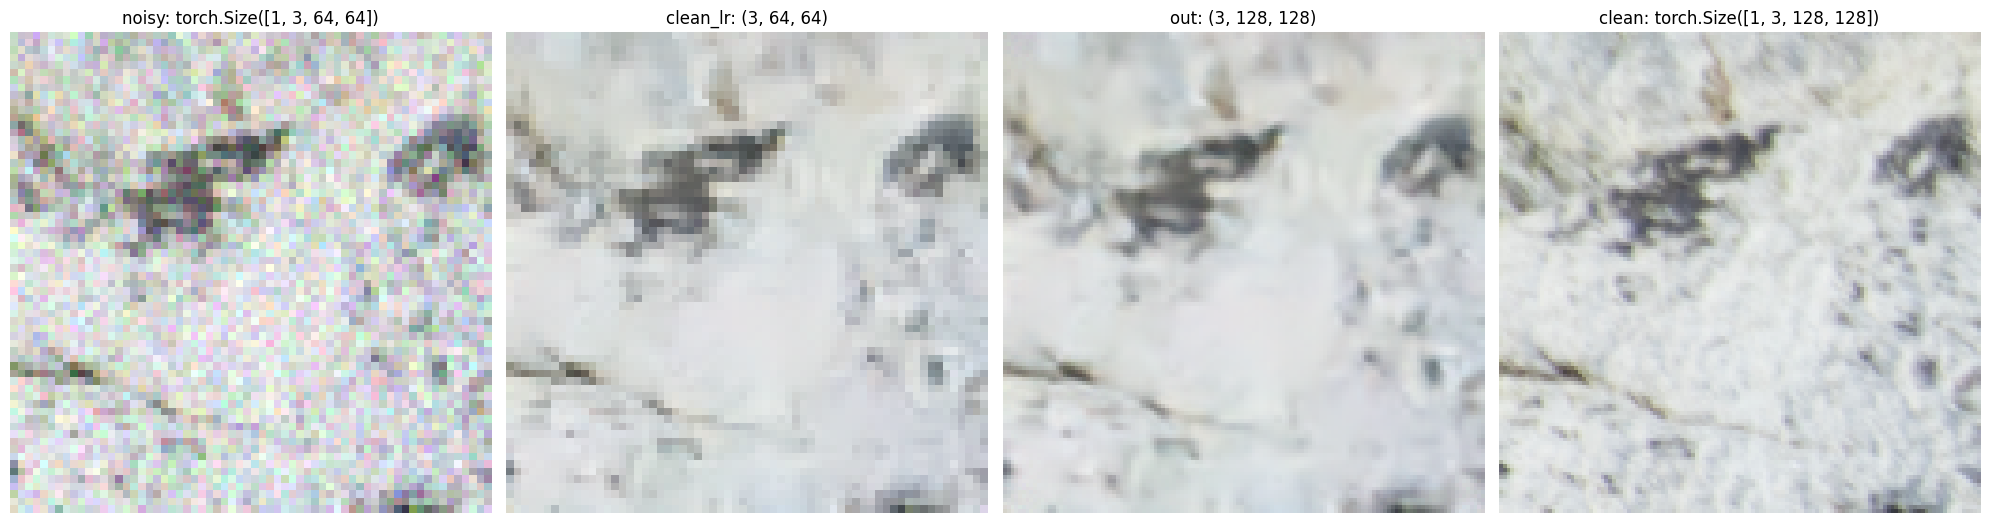

In [398]:
fig, axes = plt.subplots(1, 4, figsize=(20, 15))

axes[0].imshow(np.transpose(noisy[0][:3, :, :], (1, 2, 0)))
axes[0].set_title(f"noisy: {noisy.shape}")
axes[0].axis('off')

axes[1].imshow(np.transpose(clean_lr.cpu().data.numpy()[0], (1, 2, 0)))
axes[1].set_title(f"clean_lr: {clean_lr.cpu().data.numpy()[0].shape}")
axes[1].axis('off')

axes[2].imshow(np.transpose(output.cpu().data.numpy()[0], (1, 2, 0)))
axes[2].set_title(f"out: {output.cpu().data.numpy()[0].shape}")
axes[2].axis('off')


axes[3].imshow(np.transpose(clean[0], (1, 2, 0)))
axes[3].set_title(f"clean: {clean.shape}")
axes[3].axis('off')

plt.tight_layout()
plt.show()